# SurvSHAP-IQ: Shapley Interactions for Survival Analysis

Compute Shapley interaction indices for multimodal survival predictions using the `shapiq` package.

**Players:**
- Top-K patches (by attention weight)
- 8 clinical feature groups (age, LN_examined, Surgery, Menopause, T-Stage, N-Stage, M-Stage, Stage)

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import random

from utils import (
    MILSurvivalModel, 
    create_feature_dataloaders, 
    get_feature_group_mapping,
    get_group_value_for_display,
    load_patch_images_for_shapiq,
    SurvivalGame
)
from pycox.models import DeepHitSingle
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from shapiq import ExactComputer

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CHECKPOINT_DIR = Path('./checkpoints')
TOP_K_PATCHES = 6

print(f"Device: {DEVICE}")

Device: cuda


## Load Model & Data

In [2]:
# Load data
df = pd.read_csv('./data/clinical_data_split.csv')
tabular_cols = [c for c in df.columns if c not in ['patient_id', 'time', 'event', 'split']]

# Fit label transformer (must match training)
labtrans = LabTransDiscreteTime(16, scheme='quantiles')
labtrans.fit(df['time'].values, df['event'].values)
TIME_BINS = labtrans.cuts.tolist()

# Transform labels
df_transformed = df.copy()[['patient_id', 'time', 'event', 'split'] + tabular_cols]
y = labtrans.transform(df_transformed['time'].values, df_transformed['event'].values)
df_transformed['idx_duration'] = y[0]
df_transformed['event_transformed'] = y[1]
df_transformed.to_csv('./data/clinical_data_transformed.csv', index=False)

print(f"Time bins: {np.round(TIME_BINS, 2)}")

Time bins: [ 0.    1.98  2.87  4.24  5.17  6.43  7.42  8.08  9.21 10.02 10.75 11.59
 17.23 17.68 19.51 23.56]


In [3]:
# Setup feature groups (one-hot encoded features grouped as single players)
feature_groups = get_feature_group_mapping(tabular_cols)

print(f"Feature Groups ({feature_groups['n_groups']} groups from {len(tabular_cols)} features):")
for group_name in feature_groups['group_names']:
    cols = feature_groups['group_to_cols'][group_name]
    col_names = [tabular_cols[i] for i in cols]
    print(f"  {group_name}: {col_names}")

Feature Groups (8 groups from 21 features):
  age: ['age']
  LN_examined: ['LN_examined']
  Surgery: ['surgery_lumpectomy', 'surgery_other', 'surgery_simple_mastectomy']
  Menopause: ['menopause_indeterminate', 'menopause_pre']
  T-Stage: ['T_T1', 'T_T3', 'T_T4', 'T_TX']
  N-Stage: ['N_N1', 'N_N2', 'N_N3', 'N_NX']
  M-Stage: ['M_M1', 'M_MX']
  Stage: ['stage_I', 'stage_III', 'stage_IV', 'stage_X']


In [4]:
# Create dataloaders (batch_size=1, all patches for interpretability)
train_loader, val_loader, test_loader = create_feature_dataloaders(
    clinical_csv='./data/clinical_data_transformed.csv',
    feature_dir='./data/extracted_features',
    batch_size=1,
    num_workers=0,
    max_patches=None  # Use ALL patches
)

TRAIN: 693 patients with features
VAL: 149 patients with features
TEST: 148 patients with features


In [5]:
# Load trained model
net = MILSurvivalModel(
    feature_dim=1536,
    num_durations=len(TIME_BINS),
    tabular_dim=len(tabular_cols),
    hidden_dim=128,
    attention_dim=64,
    dropout=0.5
).to(DEVICE)

net.load_state_dict(torch.load(CHECKPOINT_DIR / 'final_model.pt', map_location=DEVICE))
net.eval()

# Create pycox model wrapper
optimizer = torch.optim.Adam(net.parameters())
model = DeepHitSingle(
    net, optimizer,
    alpha=0.2, sigma=0.1,
    duration_index=TIME_BINS,
    device=DEVICE
)
model.net.eval()

print(f"Model loaded: {sum(p.numel() for p in net.parameters()):,} parameters")

Model loaded: 438,331 parameters


In [6]:
from pathlib import Path
import numpy as np

# Calculate number of patches per patient
path = "./data/extracted_features"
patch_counts = {}

for patient_file in Path(path).iterdir():
    batch = np.load(patient_file)
    num_patches = batch.shape[0]
    patch_counts[patient_file.name] = num_patches

# Print min, meadian, mean, and max number of patches
patch_numbers = list(patch_counts.values())
print(f"Patch counts - min: {np.min(patch_numbers)}")
print(f"Patch counts - median: {np.median(patch_numbers)}")
print(f"Patch counts - mean: {np.mean(patch_numbers):.2f}")
print(f"Patch counts - max: {np.max(patch_numbers)}")

Patch counts - min: 50
Patch counts - median: 466.0
Patch counts - mean: 523.38
Patch counts - max: 2345


## Prepare Background Data for Marginal Imputation

In [7]:
# Create background patch pool from training data
n_background = len(train_loader.dataset)
n_patches_per_patient = 500

random.seed(123)
train_data_patches = []
train_data_tabular = []

for idx in random.sample(range(len(train_loader.dataset)), n_background):
    (patches, tabular), _, patient_id = train_loader.dataset[idx]
    if len(patches) < n_patches_per_patient:
        patch_idx = torch.randint(0, len(patches), (n_patches_per_patient,))
    else:
        patch_idx = torch.randperm(len(patches))[:n_patches_per_patient]
    patches = patches[patch_idx]
    train_data_patches.append(patches.unsqueeze(0))
    train_data_tabular.append(tabular)

train_data_patches = torch.cat(train_data_patches, dim=0)
train_data_tabular = torch.stack(train_data_tabular, dim=0)

print(f"Background data: {train_data_patches.shape[0]} patients, {n_patches_per_patient} patches each")

Background data: 693 patients, 500 patches each


## Compute Shapley Interactions for a Single Patient

In [8]:
# Select a test patient
PATIENT_IDX = 127  # Change this to analyze different patients
TIME_IDX = 3       # Time bin index for explanation

(patch_features, tabular), (idx_duration, event), patient_id = test_loader.dataset[PATIENT_IDX]
patch_features = patch_features.unsqueeze(0).to(DEVICE)
tabular = tabular.unsqueeze(0).to(DEVICE)

# Get attention weights
with torch.no_grad():
    _, attention_weights = net(patch_features, tabular, return_attention=True)
attention_weights = attention_weights.cpu().numpy()[0]

# Select top-K patches
top_k_indices = np.argsort(attention_weights)[-TOP_K_PATCHES:][::-1]
boolean_mask = np.zeros(patch_features.shape[1], dtype=bool)
boolean_mask[top_k_indices] = True
patch_features_top_k = patch_features[:, boolean_mask, :]

print(f"Patient: {patient_id}")
print(f"Total patches: {patch_features.shape[1]}")
print(f"Top-{TOP_K_PATCHES} patches: {top_k_indices}")
print(f"Combined attention: {attention_weights[top_k_indices].sum()*100:.1f}%")

Patient: TCGA-A7-A13D
Total patches: 267
Top-6 patches: [255 246  31  62 146  40]
Combined attention: 21.9%


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


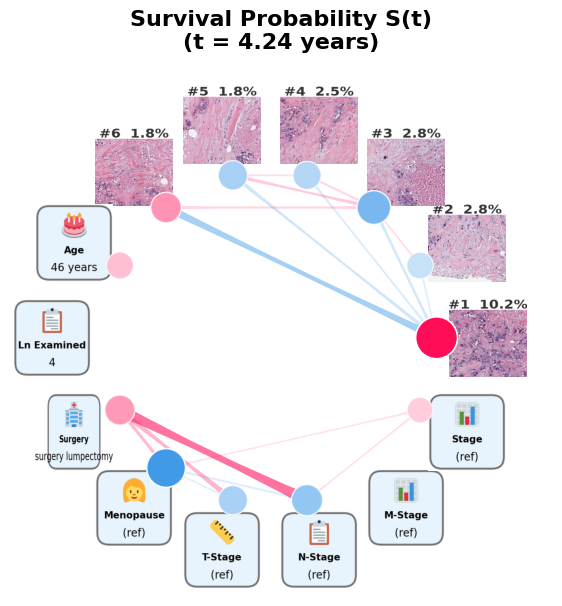

Saved: ./plots/sii_TCGA-A7-A13D_surv.png
Sum of SII values: 0.0237



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


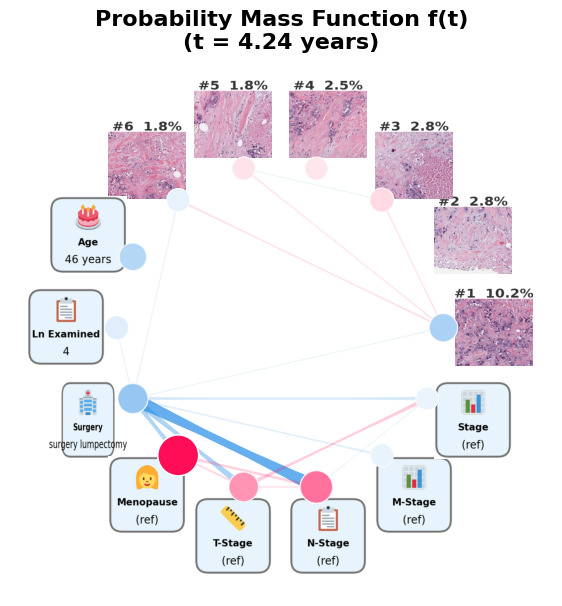

Saved: ./plots/sii_TCGA-A7-A13D_pmf.png
Sum of SII values: -0.0052



In [9]:
# Compute Shapley interactions for S(t) and f(t)
Path('./plots').mkdir(exist_ok=True)

for prediction_method in ['predict_surv', 'predict_pmf']:
    # Create cooperative game
    game = SurvivalGame(
        pycox_model=model,
        x=(patch_features_top_k, tabular),
        x_other_patches=patch_features[:, ~boolean_mask, :],
        time_idx=TIME_IDX,
        baseline_patch='marginal_patient',
        baseline_tabular='marginal',
        data_patch=train_data_patches,
        data_tabular=train_data_tabular,
        n_background_samples=n_background,
        prediction_method=prediction_method,
        device=DEVICE,
        verbose=False,
        feature_groups=feature_groups
    )
    
    # Compute exact Shapley interaction indices
    game.precompute()
    exact = ExactComputer(n_players=game.n_players, game=game)
    sii = exact(index="k-SII", order=2)
    
    # Prepare visualization
    group_values = get_group_value_for_display(tabular, feature_groups, tabular_cols)
    tabular_dict = {name: group_values[name] for name in feature_groups['group_names']}
    
    images = load_patch_images_for_shapiq(
        patient_id=patient_id,
        top_k_indices=top_k_indices,
        tabular_features=tabular_dict,
        img_dir=Path('./data/processed_images'),
        show_rank=True,
        title_height=36,
        title_font_size=40,
        attention_weights=attention_weights
    )
    
    feat_names = [f"Patch {i}" for i in range(1, TOP_K_PATCHES + 1)] + feature_groups['group_names']
    
    # Plot network
    fig, ax = sii.plot_network(
        feature_names=feat_names, 
        n_interactions=30, 
        feature_image_patches=images, 
        show=False, 
        size_factor=2.5
    )
    
    out_label = "Survival Probability S(t)" if prediction_method == 'predict_surv' else "Probability Mass Function f(t)"
    ax.set_title(f"{out_label}\n(t = {TIME_BINS[TIME_IDX]:.2f} years)", fontsize=16, fontweight='bold')
    
    # Optionally overlay WSI
    try:
        wsi_path = Path(f"./data/original_data/{patient_id}.png")
        if wsi_path.exists():
            orig_image = Image.open(wsi_path).convert('RGB')
            ax.imshow(orig_image, extent=(-0.7, 0.7, -0.7, 0.7), zorder=0, alpha=1)
    except:
        pass
    
    filename = f"./plots/sii_{patient_id}_{prediction_method.split('_')[1]}.png"
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {filename}")
    print(f"Sum of SII values: {sii.values.sum() - sii.baseline_value:.4f}\n")